Subir los ficheros del INE
- Alta_Diagnostico_Provincia.xlsx
- Alta_Motivo_Ingreso.xlsx
- Estancia_media_xlsx

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Alta_Diagnostico_Provincia.xlsx to Alta_Diagnostico_Provincia.xlsx
Saving Alta_Motivo_ingreso.xlsx to Alta_Motivo_ingreso.xlsx
Saving Estancia_media.xlsx to Estancia_media.xlsx


Configuración

In [9]:
import matplotlib.pyplot as plt
import openpyxl
import os
import pandas as pd
import re

DATA_DIR = "."
OUT_DIR = "./eda_assets_2023"
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CHAPTER_RE = re.compile(r"^(\d{4})\s+(.*)")

Alta_Diagnostico_Provincia (distribución por CCAA y diagnóstico ¡)

/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


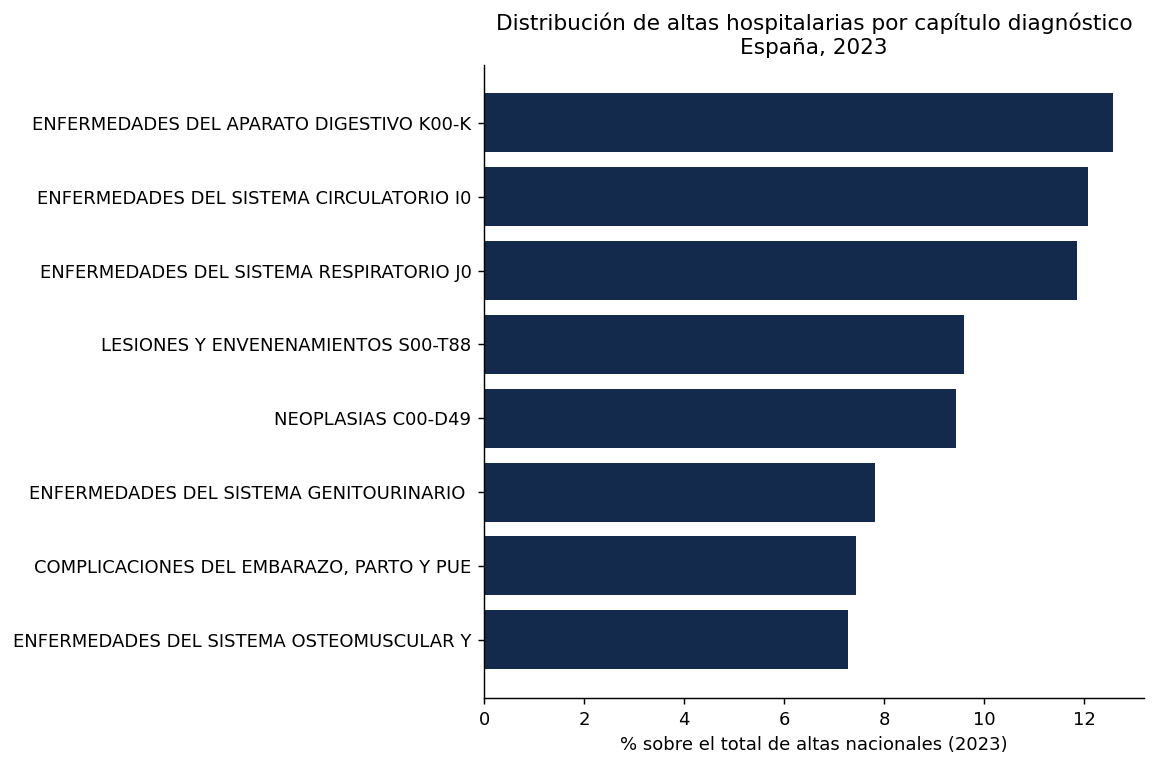

In [10]:
wb = openpyxl.load_workbook(f"{DATA_DIR}/Alta_Diagnostico_Provincia.xlsx", read_only=True, data_only=True)
ws = wb["tabla-74901"]
rows = list(ws.iter_rows(values_only=True))
header = rows[6]

CCAA_COLS = {
    "Andalucía": 2, "Aragón": 11, "Asturias": 15, "Baleares": 16, "Canarias": 17,
    "Cantabria": 20, "Castilla y León": 21, "Castilla-La Mancha": 31, "Cataluña": 37,
    "C. Valenciana": 42, "Extremadura": 46, "Galicia": 49, "Madrid": 54, "Murcia": 55,
    "Navarra": 56, "País Vasco": 57, "La Rioja": 61, "Ceuta": 62, "Melilla": 63,
}
COL_NACIONAL = 1

chapters = []
for i in range(8, 158):
    label = rows[i][0]
    if not label:
        continue
    m = CHAPTER_RE.match(label.strip())
    if m and m.group(1).endswith("00") and m.group(1) != "0000":
        chapters.append((i, m.group(1), m.group(2)[:40]))

total_nacional = rows[8][COL_NACIONAL]

nat = pd.Series({name: rows[i][COL_NACIONAL] for i, code, name in chapters}).sort_values(ascending=False)
nat_pct = nat / total_nacional * 100

fig, ax = plt.subplots(figsize=(9, 6))
top8 = nat_pct.head(8)[::-1]
ax.barh(top8.index, top8.values, color="#132a4c")
ax.set_xlabel("% sobre el total de altas nacionales (2023)")
ax.set_title("Distribución de altas hospitalarias por capítulo diagnóstico\nEspaña, 2023")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_top_diagnosticos_nacional.png")
plt.show()

Peso de los 3 capítulos principales por CCAA

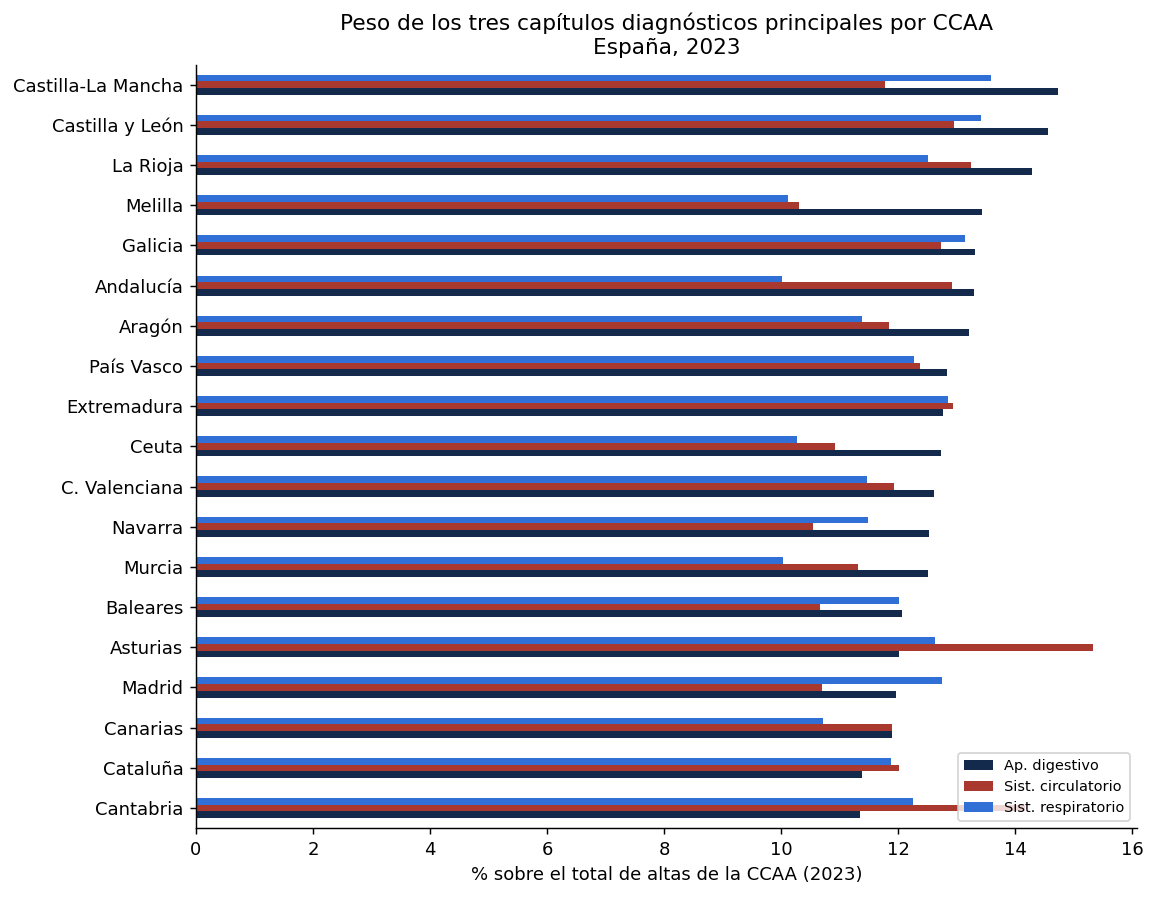

In [11]:
code_to_label = {"1100": "Ap. digestivo", "0900": "Sist. circulatorio", "1000": "Sist. respiratorio"}
idx_by_code = {code: i for i, code, _ in chapters if code in code_to_label}

data_ccaa = {}
for ccaa, col in CCAA_COLS.items():
    total_ccaa = rows[8][col]
    fila = {}
    for code, label in code_to_label.items():
        val = rows[idx_by_code[code]][col]
        fila[label] = val / total_ccaa * 100 if total_ccaa else None
    data_ccaa[ccaa] = fila

df_ccaa = pd.DataFrame(data_ccaa).T.sort_values("Ap. digestivo")

fig, ax = plt.subplots(figsize=(9, 7))
df_ccaa.plot(kind="barh", stacked=False, ax=ax, color=["#132a4c", "#a9382f", "#2f6fd6"])
ax.set_xlabel("% sobre el total de altas de la CCAA (2023)")
ax.set_title("Peso de los tres capítulos diagnósticos principales por CCAA\nEspaña, 2023")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_diagnosticos_por_ccaa.png")
plt.show()

Alta_Motivo_Ingreso: tasas de traslado y fallecimiento

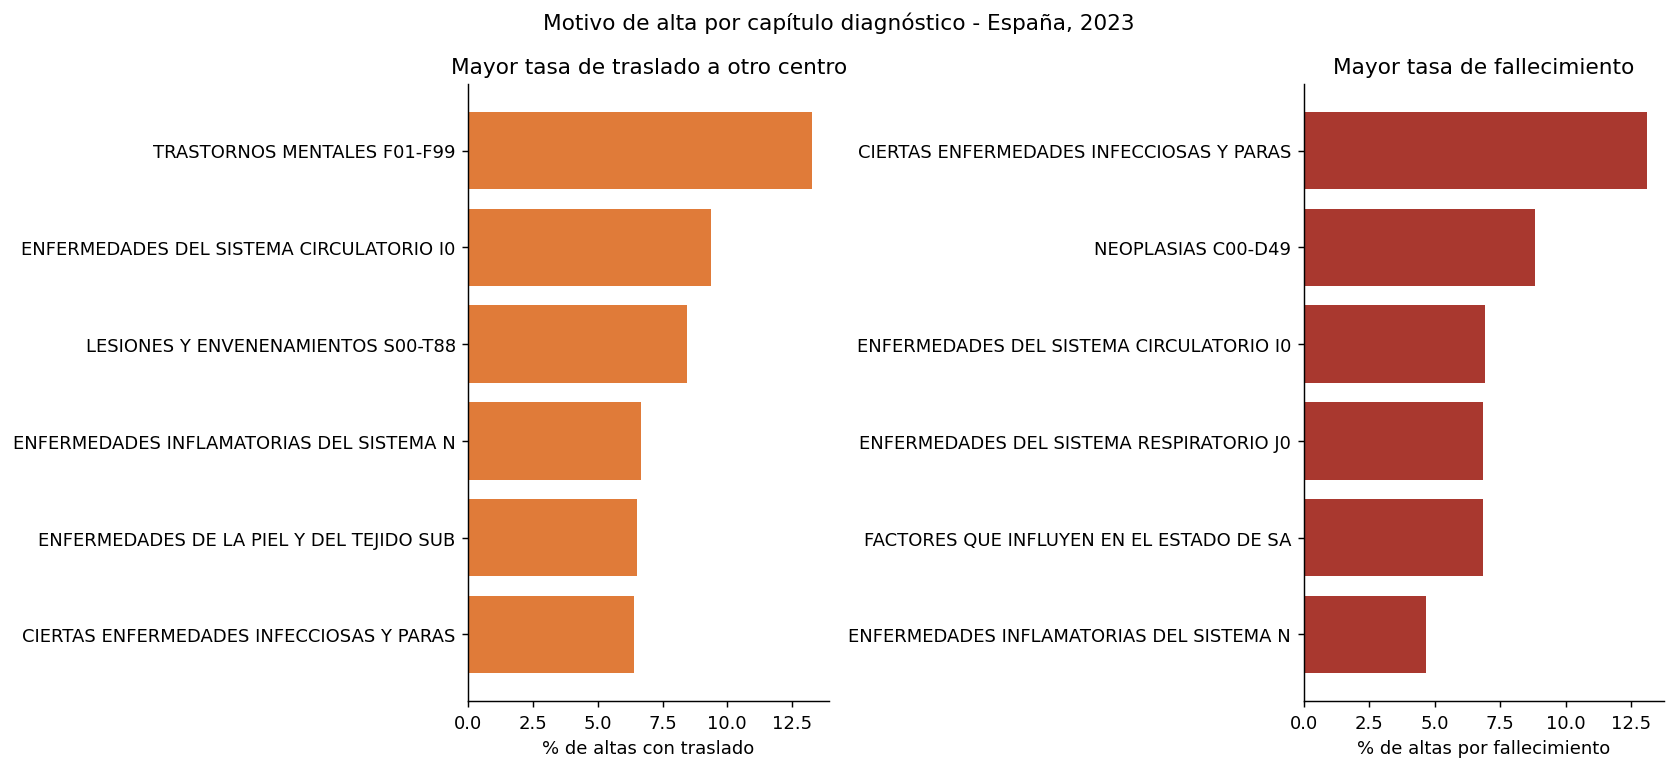

In [12]:

wb2 = openpyxl.load_workbook(f"{DATA_DIR}/Alta_Motivo_ingreso.xlsx", read_only=True, data_only=True)
ws2 = wb2["tabla-74880"]
rows2 = list(ws2.iter_rows(values_only=True))

chapters2 = []
for i in range(8, 160):
    label = rows2[i][0]
    if not label:
        continue
    m = CHAPTER_RE.match(label.strip())
    if m and m.group(1).endswith("00") and m.group(1) != "0000":
        chapters2.append((i, m.group(1), m.group(2)[:40]))

motivo = []
for i, code, name in chapters2:
    total, curacion, traslado, fallecimiento = rows2[i][1], rows2[i][2], rows2[i][3], rows2[i][4]
    if total:
        motivo.append({
            "diagnostico": name, "n": total,
            "tasa_traslado": traslado / total * 100,
            "tasa_fallecimiento": fallecimiento / total * 100,
        })
df_motivo = pd.DataFrame(motivo)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
top_traslado = df_motivo.sort_values("tasa_traslado", ascending=False).head(6).iloc[::-1]
axes[0].barh(top_traslado["diagnostico"], top_traslado["tasa_traslado"], color="#e07b39")
axes[0].set_title("Mayor tasa de traslado a otro centro")
axes[0].set_xlabel("% de altas con traslado")

top_fallecimiento = df_motivo.sort_values("tasa_fallecimiento", ascending=False).head(6).iloc[::-1]
axes[1].barh(top_fallecimiento["diagnostico"], top_fallecimiento["tasa_fallecimiento"], color="#a9382f")
axes[1].set_title("Mayor tasa de fallecimiento")
axes[1].set_xlabel("% de altas por fallecimiento")

fig.suptitle("Motivo de alta por capítulo diagnóstico - España, 2023")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_traslado_fallecimiento.png")
plt.show()

Estancia_media: estancia media por diagnóstico x edad

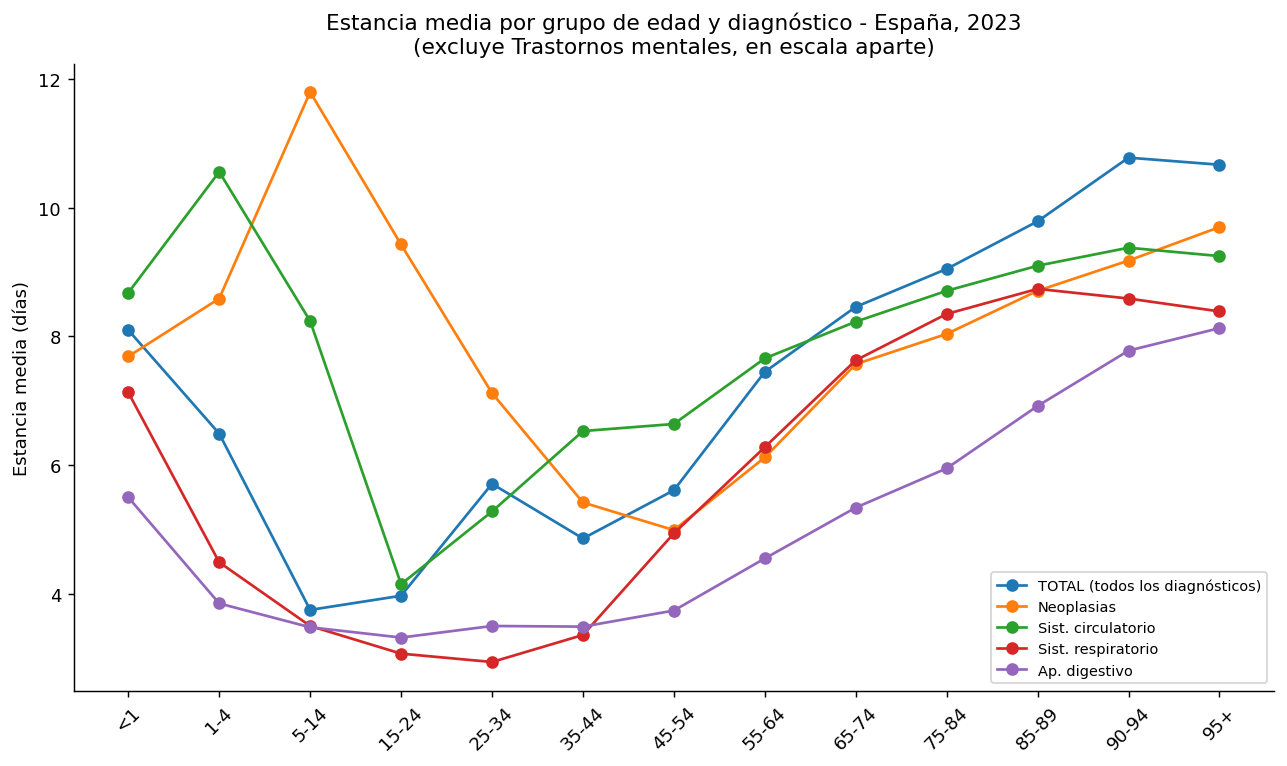

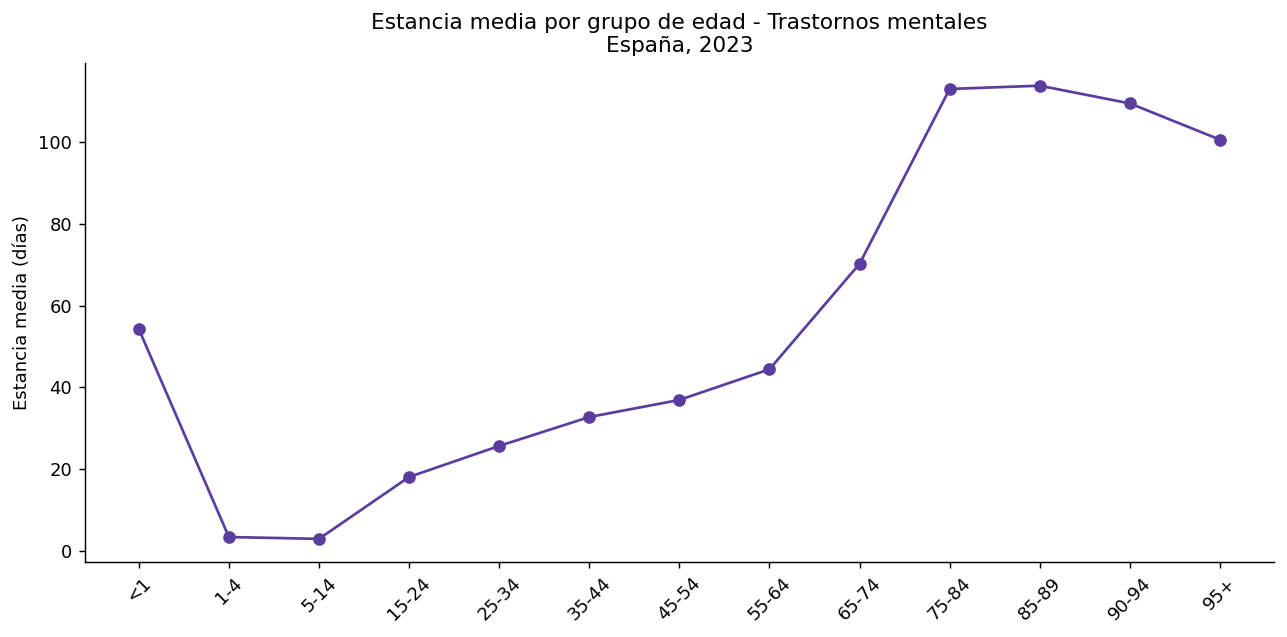

In [13]:
wb3 = openpyxl.load_workbook(f"{DATA_DIR}/Estancia_media.xlsx", read_only=True, data_only=True)
ws3 = wb3["tabla-74890"]
rows3 = list(ws3.iter_rows(values_only=True))

edades = ["<1", "1-4", "5-14", "15-24", "25-34", "35-44", "45-54", "55-64",
          "65-74", "75-84", "85-89", "90-94", "95+"]

chapters_edad = {"0900": "Sist. circulatorio", "1000": "Sist. respiratorio",
                  "1100": "Ap. digestivo", "0200": "Neoplasias", "0500": "Trastornos mentales"}

series_edad = {"TOTAL (todos los diagnósticos)": rows3[8][1:14]}
for i in range(8, 160):
    label = rows3[i][0]
    if not label:
        continue
    m = CHAPTER_RE.match(label.strip())
    if m and m.group(1) in chapters_edad:
        series_edad[chapters_edad[m.group(1)]] = rows3[i][1:14]

df_edad = pd.DataFrame(series_edad, index=edades)

fig, ax = plt.subplots(figsize=(10, 6))
for col in df_edad.columns:
    if col == "Trastornos mentales":
        continue
    ax.plot(df_edad.index, df_edad[col], marker="o", label=col)
ax.set_ylabel("Estancia media (días)")
ax.set_title("Estancia media por grupo de edad y diagnóstico - España, 2023\n(excluye Trastornos mentales, en escala aparte)")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_estancia_edad.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_edad.index, df_edad["Trastornos mentales"], marker="o", color="#5a3d9e")
ax.set_ylabel("Estancia media (días)")
ax.set_title("Estancia media por grupo de edad - Trastornos mentales\nEspaña, 2023")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/fig_estancia_edad_trastornos_mentales.png")
plt.show()

Resumen numérico para citar en el texto del TFM

In [14]:
print("=== Top capítulos nacional (% sobre total) ===")
print(nat_pct.head(6).round(1))

print("\n=== Top 1 capítulo por CCAA ===")
for ccaa in df_ccaa.index:
    row = df_ccaa.loc[ccaa]
    top_col = row.idxmax()
    print(f"{ccaa}: {top_col} ({row[top_col]:.1f}%)")

print("\n=== Tasa de traslado (top 5) ===")
print(df_motivo.sort_values("tasa_traslado", ascending=False).head(5)[["diagnostico", "tasa_traslado"]])

print("\n=== Tasa de fallecimiento (top 5) ===")
print(df_motivo.sort_values("tasa_fallecimiento", ascending=False).head(5)[["diagnostico", "tasa_fallecimiento"]])

tot = rows2[8]
print("\n=== Tasas nacionales globales ===")
print("Traslado global:", round(tot[3] / tot[1] * 100, 2), "%")
print("Fallecimiento global:", round(tot[4] / tot[1] * 100, 2), "%")

print("\n=== Estancia media por edad (extracto) ===")
print(df_edad.round(1))

df_motivo.to_csv(f"{OUT_DIR}/motivo_alta_por_diagnostico.csv", index=False)
df_edad.to_csv(f"{OUT_DIR}/estancia_media_por_edad_diagnostico.csv")
df_ccaa.to_csv(f"{OUT_DIR}/diagnosticos_principales_por_ccaa.csv")

df_edad  # muestra la tabla en Colab


=== Top capítulos nacional (% sobre total) ===
ENFERMEDADES DEL APARATO DIGESTIVO K00-K    12.6
ENFERMEDADES DEL SISTEMA CIRCULATORIO I0    12.1
ENFERMEDADES DEL SISTEMA RESPIRATORIO J0    11.9
LESIONES Y ENVENENAMIENTOS S00-T88           9.6
NEOPLASIAS C00-D49                           9.4
ENFERMEDADES DEL SISTEMA GENITOURINARIO      7.8
dtype: float64

=== Top 1 capítulo por CCAA ===
Cantabria: Sist. circulatorio (14.2%)
Cataluña: Sist. circulatorio (12.0%)
Canarias: Sist. circulatorio (11.9%)
Madrid: Sist. respiratorio (12.8%)
Asturias: Sist. circulatorio (15.3%)
Baleares: Ap. digestivo (12.1%)
Murcia: Ap. digestivo (12.5%)
Navarra: Ap. digestivo (12.5%)
C. Valenciana: Ap. digestivo (12.6%)
Ceuta: Ap. digestivo (12.7%)
Extremadura: Sist. circulatorio (12.9%)
País Vasco: Ap. digestivo (12.8%)
Aragón: Ap. digestivo (13.2%)
Andalucía: Ap. digestivo (13.3%)
Galicia: Ap. digestivo (13.3%)
Melilla: Ap. digestivo (13.4%)
La Rioja: Ap. digestivo (14.3%)
Castilla y León: Ap. digestivo (14.6%

,TOTAL (todos los diagnósticos),Neoplasias,Trastornos mentales,Sist. circulatorio,Sist. respiratorio,Ap. digestivo
<1,8.10,7.69,54.26,8.68,7.13,5.50
1-4,6.49,8.59,3.43,10.56,4.49,3.85
5-14,3.75,11.80,2.99,8.24,3.50,3.48
15-24,3.97,9.43,18.11,4.15,3.07,3.32
25-34,5.71,7.12,25.69,5.28,2.94,3.50
35-44,4.86,5.42,32.76,6.53,3.36,3.49
45-54,5.61,4.99,36.93,6.64,4.94,3.74
55-64,7.45,6.12,44.43,7.66,6.28,4.55
65-74,8.46,7.57,70.19,8.23,7.63,5.34
75-84,9.05,8.04,112.92,8.71,8.35,5.95


Descargar gráficos y CSV

In [15]:
import shutil
shutil.make_archive("eda_assets_2023", "zip", OUT_DIR)
files.download("eda_assets_2023.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>